## AQ1: How well does the MORL personalization algorithm address and balance the diverse needs and concerns from different stakeholders?

This notebook evaluates personalization algorithm's ability to balance objectives of multiple stakeholders through simulation with synthetic users. This analysis is used to obtain the results in Chapter 4.2 of the thesis, to generate the accompanying figures and for some tables and figures in the Appendix. The analysis compares:

**Multi-Objective Reinforcement Learning (MORL) Approaches:**
- **MORL-EP**: Expert Priority Metapolicy - policy that prioritizes expert-driven objectives (adherence, return willingness and diversity)
- **MORL-UC**: User Choice Metapolicy - allows users to choose from three optimal challenges
- **MORL-UC+EP**: Combination of user choice and expert priority - user choice, switches to expert priority after 12 challenge completions.

**Comparison Policies:**
- **C-Corr**: Correlation-based - weights objectives by their correlation with completion
- **C-Eq**: Equal weights - equally balances all objectives
- **Random**: No policy - random challenge selection
- **SO-***: Single-objective policies optimizing only one objective

**Outcomes Measured:**
- Adolescent-driven: Perceived Enjoyment, Perceived Usefulness, Time Appropriateness
- Expert-driven: Adherence, Return Willingness, Diversity (engagement and personalization)

**Author:** Shirley Li  
**Date:** July 2026

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyperclip

sys.path.append(os.path.abspath('..'))
from env.user_sim import UserSimEnv
import utils.process_data as dp
import utils.plot_figures as pf
import utils.utils as utils
import config

palette = sns.color_palette("muted")
sns.set_palette(palette)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [ ]:
state_to_idx, idx_to_state = utils.build_state_space(config.NUM_VALS_PER_FEATURE)

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_corrected_full.csv'))
actions_clustered, _, _ = dp.cluster_actions(action_data, config.cluster_vars, num_clusters=config.NUM_CLUSTERS)

df, agency_df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, config.state_features, config.NUM_VALS_PER_FEATURE, config.action_col, config.cluster_col)

### Get number of samples per (s,a)-pair

In [3]:
counts_per_pair = df.groupby(['s_idx', config.action_col]).size().unstack(fill_value=0)
counts_per_pair['Total'] = counts_per_pair.sum(axis=1)
counts_per_pair['State'] = counts_per_pair.index.map(lambda x: idx_to_state[x])
counts_per_pair = counts_per_pair.reset_index(drop=True)
counts_per_pair.rename(columns=lambda x: utils.action_idx_to_action(x) if x != 'State' and x != 'Total' else x, inplace=True)
counts_per_pair.set_index('State', inplace=True)
latex = counts_per_pair.to_latex()
pyperclip.copy(latex)

### Load simulation results

In [ ]:
results_folder = "C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\"
simulation_file = "\\pimorld_P=128_gamma=0.7_MOT_adh\\simulations\\combined_simulation_results.pkl"
simulation_results = pd.read_pickle(results_folder + simulation_file)

Standardize policy names and extract outcomes

In [6]:
policy_abbreviations = {
    "Multipolicy random": "MORL-UC",
    "Multipolicy most_likely": "MORL-UC",
    "Multipolicy random expert": "MORL-RE",
    "Multipolicy expert_priority": "MORL-EP",
    "Multipolicy combined": "MORL-UC+EP",
    "Multipolicy informed_most_likely": "MORL-IUC",
    "Equal Weights Policy": "C-Eq",
    "Correlation-based Policy": "C-Corr",
    "SO-Difficulty-Weighted Adherence": "SO-Adherence",
}

simulation_results['policy'] = simulation_results['policy'].apply(lambda x: policy_abbreviations.get(x, x))
simulation_results['policy'] = simulation_results['policy'].apply(lambda x: str(x).replace("S-", "SO-"))

simulation_results[config.reward_names] = pd.DataFrame(
    simulation_results["rewards"].tolist(),
    index=simulation_results.index
)

### Helper functions for formatting output to latex

In [8]:
def format_cell(mean, imp, is_random):
    if is_random:
        return f"{mean:.2f}"
    arrow = "+" if imp > 0 else "-"
    return f"\\makecell{{{mean:.2f}\\\\({arrow}{abs(imp):.2f}\\%)}}"

def format_latex_to_clipboard(latex):
    latex = latex.replace("\\begin{table}", "\\begin{table}[ht]\\centering\\begin{threeparttable}")
    latex = latex.replace("\\end{table}", "\\begin{tablenotes}\\footnotesize\\item Policy abbreviations: MORL-EP = MORL with Expert Priority; MORL-UC = User Choice; MORL-UC+EP = Combination; C-Corr = Correlation-based policy; C-Eq = Equal weights policy.\\end{tablenotes}\\end{threeparttable}\\end{table}")
    pyperclip.copy(latex)

## Obtain policy performance and improvements

For each policy, compute mean values across all simulated users for each outcome measure (enjoyment, usefulness, return willingness, diversity, adherence, time appropriateness). Calculate percentage improvement over the random baseline policy to assess relative effectiveness.

In [9]:
# analyze per time state, the time spent on the activity
simulation_results["Time State"] = simulation_results["state"].apply(lambda x: x[1])
simulation_results["challenge_time"] = action_data.loc[simulation_results["challenge_id"], "time_spent"].values

mean_time_spent_per_user = simulation_results.groupby(["policy", "user", "Time State"])["challenge_time"].mean().reset_index()
mean_time_spent_per_policy_time = mean_time_spent_per_user.groupby(["policy", "Time State"])["challenge_time"].mean().unstack()
mean_time_spent_per_policy_time["ratio"] = (
    mean_time_spent_per_policy_time[1] / mean_time_spent_per_policy_time[0]
)
baseline_ratio = mean_time_spent_per_policy_time.loc["Random", "ratio"]
mean_time_spent_per_policy_time['improvement'] = mean_time_spent_per_policy_time["ratio"].subtract(baseline_ratio).div(baseline_ratio) * 100

In [10]:
expert_driven_outcomes = ["Return Willingness", "Diversity"]
policy_means = simulation_results.groupby("policy")[expert_driven_outcomes].mean()

# Calculate adherence per policy
completion_per_user = simulation_results.groupby(["policy", "user"])["completed"].sum().reset_index()
completion_per_user["Adherence"] = completion_per_user["completed"].div(config.NUM_TIMESTEPS)
policy_means["Adherence"] = completion_per_user.groupby("policy")["Adherence"].mean()
policy_means["Time Appropriateness"] = mean_time_spent_per_policy_time['ratio']

# User-driven outcomes
completed = simulation_results["completed"] == 1
user_driven_outcomes = ["Perceived Enjoyment", "Perceived Usefulness"]
for col in user_driven_outcomes:
    policy_means[col] = simulation_results.groupby("policy")[col].mean()
    policy_means[col + " (Completed)"] = simulation_results[completed].groupby("policy")[col].mean()

baseline = policy_means.loc["Random"]

improvements_over_random = policy_means.subtract(baseline).divide(baseline) * 100
# improvements_over_random['Time Appropriateness'] = mean_time_spent_per_policy_time['improvement']

max_improvements = improvements_over_random.max().to_frame(name='Max Improvement')
max_improvements["Best Policy"] = improvements_over_random.idxmax()

display(max_improvements)


,Max Improvement,Best Policy
Return Willingness,10.249657,SO-Return Willingness
Diversity,22.545674,C-Eq
Adherence,21.369878,SO-Adherence
Time Appropriateness,83.006755,SO-Return Willingness
Perceived Enjoyment,29.851931,C-Corr
Perceived Enjoyment (Completed),8.450045,SO-Perceived Usefulness
Perceived Usefulness,30.204479,SO-Perceived Usefulness
Perceived Usefulness (Completed),9.927999,SO-Perceived Usefulness


## Main Results

Analysis of primary multi-objective policies (MORL-EP, MORL-UC, MORL-UC+EP) against baselines (C-Corr, C-Eq, Random).


In [11]:
policies_to_show = ["C-Corr", "C-Eq", "MORL-EP", "MORL-UC", "MORL-UC+EP", "Random"]
main_df = simulation_results[simulation_results['policy'].isin(policies_to_show)]

### Trade-offs across stakeholder needs
Absolute improvements in outcomes over the random baseline

In [ ]:
summary_combined = policy_means[policy_means.index.isin(policies_to_show)][user_driven_outcomes + ['Time Appropriateness'] + expert_driven_outcomes + ["Adherence"]].copy()
for col in user_driven_outcomes + ['Time Appropriateness'] + expert_driven_outcomes + ["Adherence"]:
    summary_combined[col] = summary_combined.apply(lambda row: format_cell(row[col], improvements_over_random.loc[row.name, col], row.name == "Random"), axis=1)
display(summary_combined)
latex = summary_combined.to_latex(escape=False, 
                       caption="Means of adolescent-driven and expert-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_combined")
format_latex_to_clipboard(latex)

,Perceived Enjoyment,Perceived Usefulness,Time Appropriateness,Return Willingness,Diversity,Adherence
policy,,,,,,
C-Corr,\makecell{5.67\\(+29.85\%)},\makecell{3.25\\(+28.39\%)},\makecell{1.26\\(+22.61\%)},\makecell{4.02\\(+2.22\%)},\makecell{0.63\\(-14.94\%)},\makecell{0.79\\(+20.25\%)}
C-Eq,\makecell{5.23\\(+19.81\%)},\makecell{2.89\\(+14.37\%)},\makecell{1.19\\(+14.89\%)},\makecell{3.91\\(-0.64\%)},\makecell{0.90\\(+22.55\%)},\makecell{0.75\\(+13.46\%)}
MORL-EP,\makecell{5.16\\(+18.37\%)},\makecell{2.79\\(+10.45\%)},\makecell{0.98\\(-5.05\%)},\makecell{3.98\\(+1.08\%)},\makecell{0.90\\(+22.49\%)},\makecell{0.75\\(+13.03\%)}
MORL-UC,\makecell{5.62\\(+28.80\%)},\makecell{3.17\\(+25.45\%)},\makecell{1.30\\(+26.10\%)},\makecell{4.06\\(+3.12\%)},\makecell{0.82\\(+11.98\%)},\makecell{0.80\\(+21.32\%)}
MORL-UC+EP,\makecell{5.38\\(+23.29\%)},\makecell{3.04\\(+20.10\%)},\makecell{1.15\\(+11.17\%)},\makecell{3.98\\(+1.26\%)},\makecell{0.83\\(+13.42\%)},\makecell{0.76\\(+15.61\%)}
Random,4.36,2.53,1.03,3.93,0.74,0.66


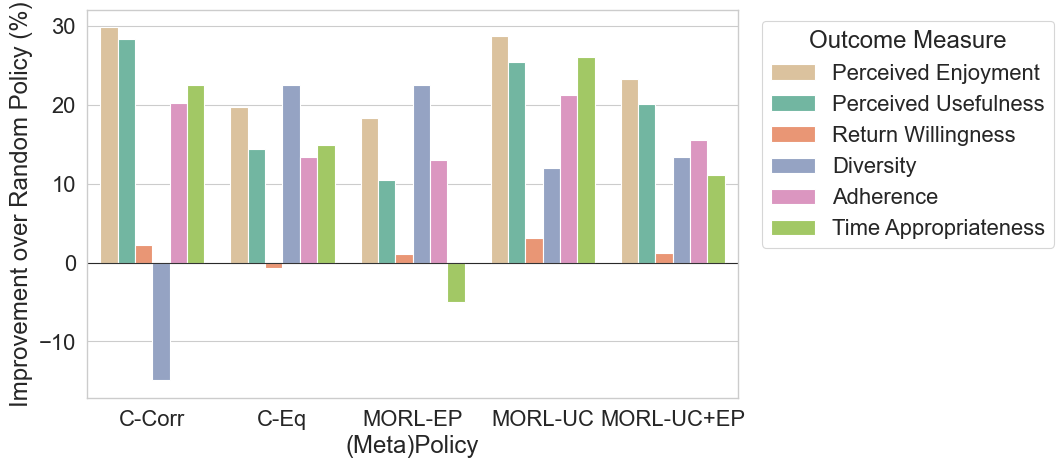

In [19]:
evaluation_names = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity", "Adherence", "Time Appropriateness"]
main_improvements = improvements_over_random.loc[policies_to_show, evaluation_names].copy()

pf.plot_improvements(main_improvements, save_path=results_folder + "\\figures\\improvements_over_random.svg")

Improvements relative to the maximum improvement observed across all policies for each outcome measure.

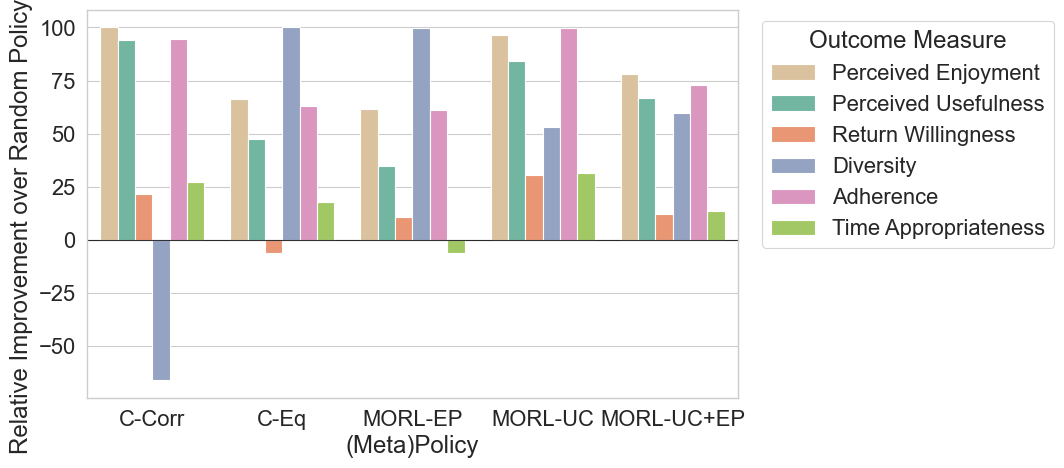

In [20]:
pf.plot_improvements(main_improvements, max_improvements, save_path=results_folder + "\\figures\\relative_improvements_over_random.svg")

### Experience of completed challenges

In [ ]:
outcomes_completed = [col + " (Completed)" for col in user_driven_outcomes]
summary_combined = policy_means[policy_means.index.isin(policies_to_show)][outcomes_completed].copy()
for col in outcomes_completed:
    summary_combined[col] = summary_combined.apply(lambda row: format_cell(row[col], improvements_over_random.loc[row.name, col], row.name == "Random"), axis=1)
display(summary_combined)
latex = summary_combined.to_latex(escape=False, 
                       caption="Means of adolescent-driven and expert-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_combined")
format_latex_to_clipboard(latex)

### Expected user retention
For this we need to load the simulation resullts that contain multiple runs of a group of users.

In [ ]:
extra_runs_file = "\\pimorld_P=128_gamma=0.7_MOT_adh\\simulations\\combined_simulation_results_multi_run.pkl"
simulation_results_extra = pd.read_pickle(results_folder + extra_runs_file)
simulation_results_extra['policy'] = simulation_results_extra['policy'].apply(lambda x: policy_abbreviations.get(x, x))
num_users_per_run = 500
num_runs = 20
pf.plot_batched_dropout(simulation_results_extra[simulation_results_extra['policy'].isin(policies_to_show)], threshold=3, batch_size=num_users_per_run, n_batches=num_runs, save_path=results_folder + "\\figures\\dropout_over_time.svg")

### Diversity of coping categories in practice

In [ ]:
sns.set_context("paper", font_scale=1.8)

fraction_per_t = pf.plot_fraction_completed(main_df, max_count_per_category=5, save_path=results_folder + "\\figures\\fraction_completed_per_category.svg")

In [ ]:
fraction_at_end = {policy: fraction[-1] for policy, fraction in fraction_per_t.items()}
print("Average fraction completed at the end of the simulation:")
random = fraction_at_end.get("Random", 0)
for policy, fraction in fraction_at_end.items():
    print(f"  {policy}: {fraction:.2f}")
    print(f"  Improvement over Random: {fraction - random:.2f} ({((fraction - random) / random * 100):.2f}%)")

### Outcomes over time

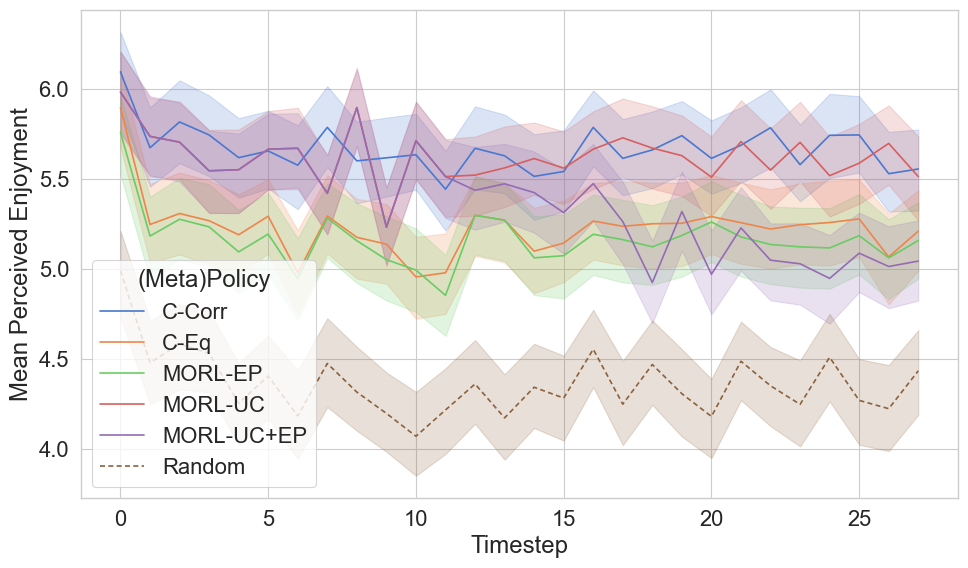

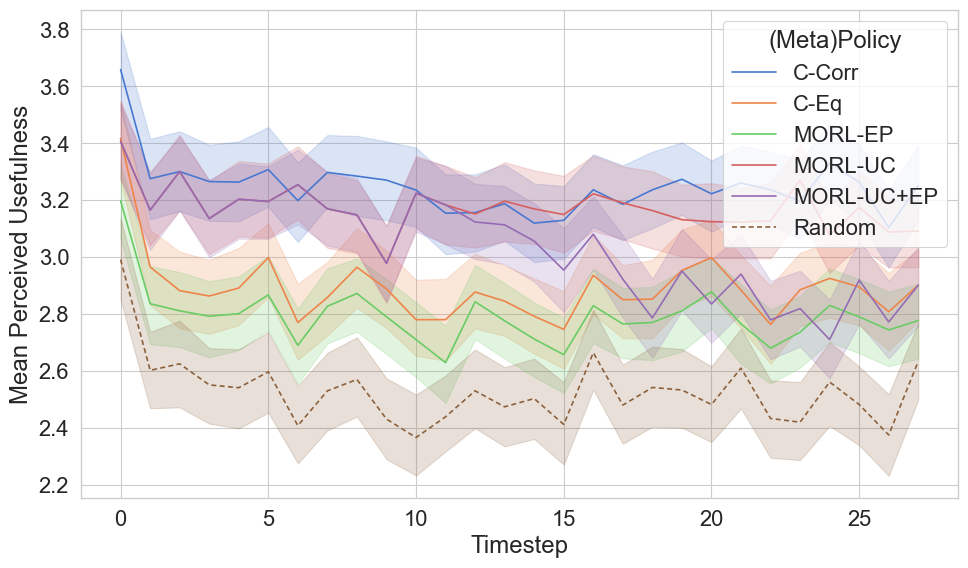

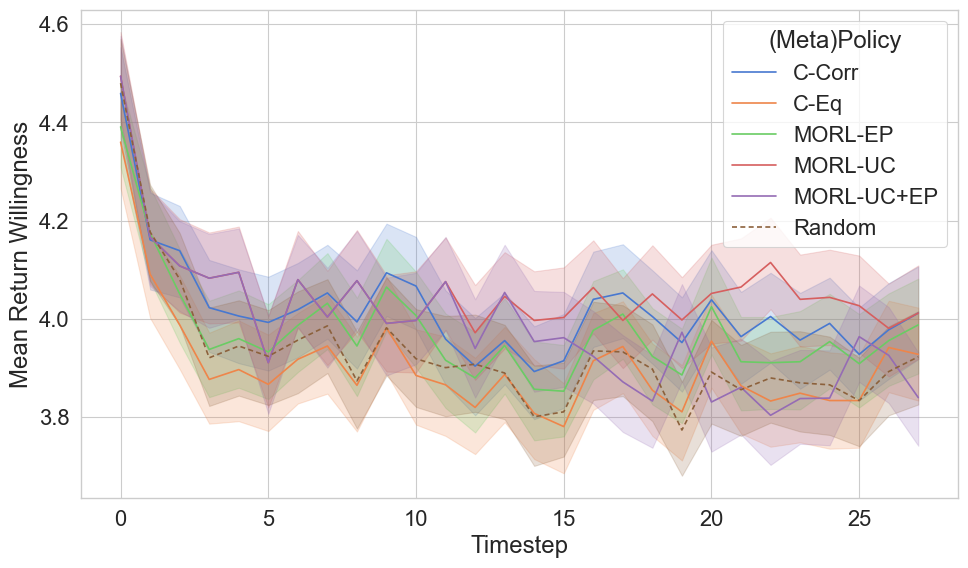

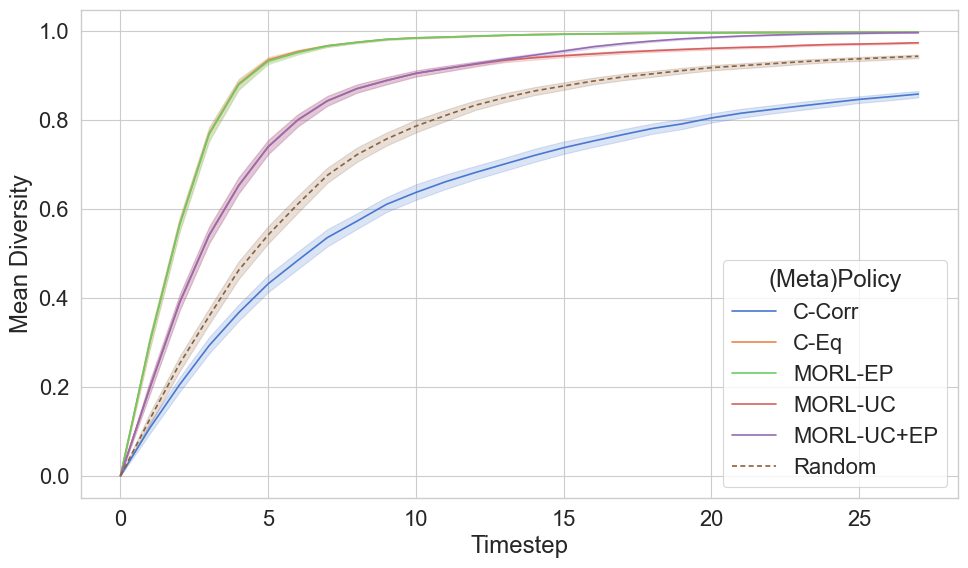

In [37]:
plotting_measures = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity"]
for measure in plotting_measures:
    pf.plot_seaborn(main_df, measure, save_path=results_folder + f"figures\\outcomes\\{measure.lower().replace(' ', '_')}.svg")

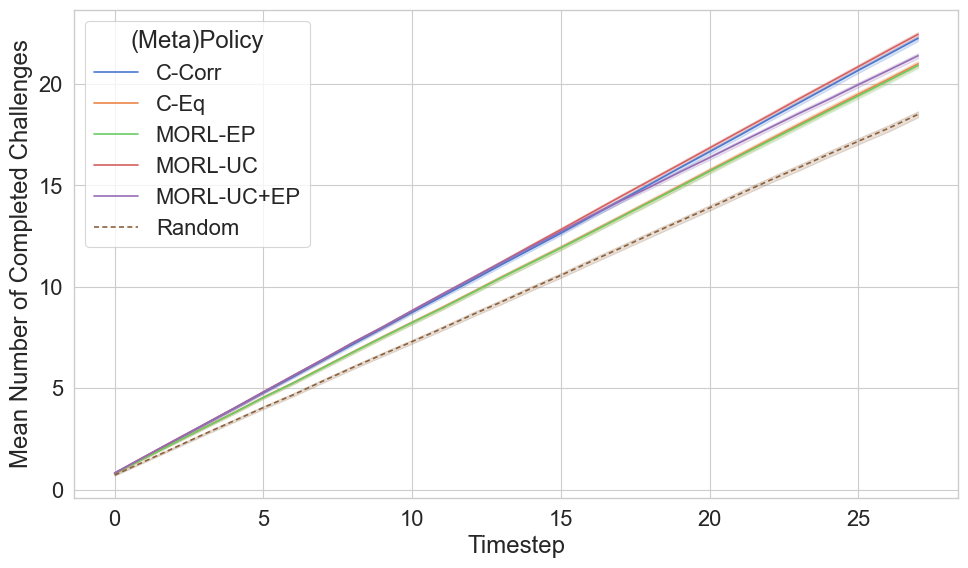

In [36]:
main_df["Number of Completed Challenges"] = main_df["num_completed"]
pf.plot_seaborn(main_df, "Number of Completed Challenges", save_path=results_folder + "figures\\outcomes\\num_completed.svg")

## Additional Results: Single-Objective Policies

Analysis of single-objective (SO) policies that optimize for only one objective.

In [27]:
so_df = simulation_results[simulation_results['policy'].str.startswith("SO")].copy()
so_policies = so_df['policy'].unique().tolist()

### Improvements over random baseline

In [32]:
summary_combined = policy_means[policy_means.index.isin(so_policies + ["Random"])][user_driven_outcomes + ['Time Appropriateness'] + expert_driven_outcomes + ["Adherence"]].copy()
for col in user_driven_outcomes + ['Time Appropriateness'] + expert_driven_outcomes + ["Adherence"]:
    summary_combined[col] = summary_combined.apply(lambda row: format_cell(row[col], improvements_over_random.loc[row.name, col], row.name == "Random"), axis=1)
display(summary_combined)
latex = summary_combined.to_latex(escape=False, 
                       caption="Means of user-driven and expert-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_combined")
format_latex_to_clipboard(latex)

,Perceived Enjoyment,Perceived Usefulness,Time Appropriateness,Return Willingness,Diversity,Adherence
policy,,,,,,
Random,4.36,2.53,1.03,3.93,0.74,0.66
SO-Adherence,\makecell{5.62\\(+28.80\%)},\makecell{3.20\\(+26.37\%)},\makecell{1.21\\(+17.62\%)},\makecell{4.02\\(+2.20\%)},\makecell{0.72\\(-2.32\%)},\makecell{0.80\\(+21.37\%)}
SO-Diversity,\makecell{3.79\\(-13.15\%)},\makecell{2.05\\(-19.06\%)},\makecell{1.20\\(+16.29\%)},\makecell{3.81\\(-3.02\%)},\makecell{0.88\\(+19.30\%)},\makecell{0.62\\(-6.32\%)}
SO-Perceived Enjoyment,\makecell{5.66\\(+29.72\%)},\makecell{3.23\\(+27.56\%)},\makecell{1.22\\(+18.47\%)},\makecell{3.97\\(+0.99\%)},\makecell{0.72\\(-2.73\%)},\makecell{0.79\\(+20.10\%)}
SO-Perceived Usefulness,\makecell{5.60\\(+28.45\%)},\makecell{3.29\\(+30.20\%)},\makecell{1.12\\(+8.18\%)},\makecell{3.97\\(+0.96\%)},\makecell{0.58\\(-20.57\%)},\makecell{0.78\\(+18.45\%)}
SO-Return Willingness,\makecell{4.90\\(+12.30\%)},\makecell{2.83\\(+11.84\%)},\makecell{1.89\\(+83.01\%)},\makecell{4.34\\(+10.25\%)},\makecell{0.51\\(-31.25\%)},\makecell{0.71\\(+7.43\%)}


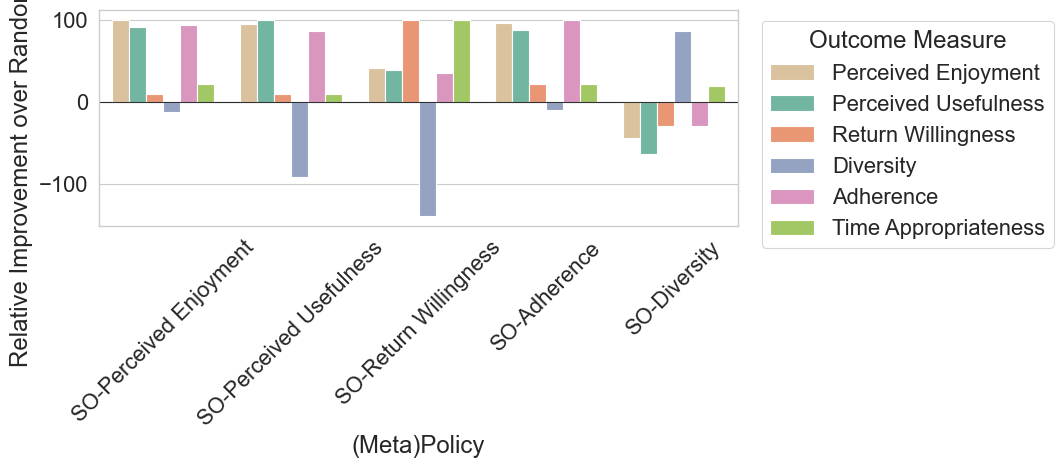

In [33]:
pf.plot_improvements(improvements_over_random.loc[so_policies + ["Random"], evaluation_names], 
                     max_improvements, 
                     save_path=results_folder + "\\figures\\extra\\relative_improvements_over_random_so.svg", 
                     ticks_rotation=45)

### Expected user retention

In [ ]:
pf.plot_batched_dropout(simulation_results_extra, threshold=3, batch_size=num_users_per_run, n_batches=num_runs, save_path=results_folder + "\\figures\\dropout_over_time_so.svg")

### Diversity of coping categories in practice

In [ ]:
fraction_per_t_so = pf.plot_fraction_completed(simulation_results, max_count_per_category=5, save_path=results_folder + "\\figures\\extra\\fraction_completed_per_category_incl_so.svg")